# Predicción de ventas netas

### Ventas - devolciones por cada día

In [1]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

ruta_ventas = '/content/drive/MyDrive/TFM_Prediccion_Ventas_LSTM_Corregido.csv'
ruta_devoluciones = '/content/drive/MyDrive/TFM_Prediccion_Devoluciones_LSTM_Corregido.csv'

ventas_test = pd.read_csv(ruta_ventas)
devoluc_test = pd.read_csv(ruta_devoluciones)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Convertimos a datetime para alinear correctamente las fechas al unir
ventas_test['Fecha'] = pd.to_datetime(ventas_test['Fecha'])
devoluc_test['Fecha'] = pd.to_datetime(devoluc_test['Fecha'])

# =============================================================================
# 2. UNIR PREDICCIONES LSTM
# =============================================================================
# Como ambos archivos tienen la columna 'Prediccion_LSTM',
# Pandas les añadirá los sufijos '_Ventas' y '_Devoluciones' automáticamente.
df_mes_objetivo = pd.merge(
    ventas_test,
    devoluc_test,
    on='Fecha',
    suffixes=('_Ventas', '_Devoluciones')
)

# =============================================================================
# 3. CÁLCULO DE VENTAS NETAS
# =============================================================================
df_mes_objetivo['Ventas_Netas_Reales'] = (
    df_mes_objetivo['Ventas_Reales'] - df_mes_objetivo['Devoluciones_Reales']
)

df_mes_objetivo['Ventas_Netas_Predichas'] = (
    df_mes_objetivo['Prediccion_LSTM_Ventas'] - df_mes_objetivo['Prediccion_LSTM_Devoluciones']
)

print("--- MUESTRA DEL DATAFRAME DE CAJA NETA ---")
display(df_mes_objetivo[['Fecha', 'Ventas_Netas_Reales', 'Ventas_Netas_Predichas']].head())

# =============================================================================
# 4. EVALUACIÓN DE MÉTRICAS (Efecto del Outlier en la Caja)
# =============================================================================
y_real_neto = df_mes_objetivo['Ventas_Netas_Reales'].values
preds_neto = df_mes_objetivo['Ventas_Netas_Predichas'].values

# a) Métricas CON el día anómalo (Pedido mayorista del 14-11-2011)
mae_con = mean_absolute_error(y_real_neto, preds_neto)
rmse_con = np.sqrt(mean_squared_error(y_real_neto, preds_neto))
r2_con = r2_score(y_real_neto, preds_neto)

# b) Métricas SIN el día anómalo
fecha_anomala = pd.to_datetime('2011-11-14')
mascara_sin_anomalia = df_mes_objetivo['Fecha'] != fecha_anomala

y_real_neto_sin = df_mes_objetivo.loc[mascara_sin_anomalia, 'Ventas_Netas_Reales'].values
preds_neto_sin = df_mes_objetivo.loc[mascara_sin_anomalia, 'Ventas_Netas_Predichas'].values

mae_sin = mean_absolute_error(y_real_neto_sin, preds_neto_sin)
rmse_sin = np.sqrt(mean_squared_error(y_real_neto_sin, preds_neto_sin))
r2_sin = r2_score(y_real_neto_sin, preds_neto_sin)

print("\n" + "="*80)
print("     RANKING DEFINITIVO: PRECISIÓN EN EL FLUJO DE CAJA NETO (LSTM)     ")
print("="*80)
print(f"{'Métrica':<15} | {'CON día 14-11':<22} | {'SIN día 14-11':<22}")
print("-" * 80)
print(f"{'MAE Neto':<15} | £ {mae_con:<20,.2f} | £ {mae_sin:<20,.2f}")
print(f"{'RMSE Neto':<15} | £ {rmse_con:<20,.2f} | £ {rmse_sin:<20,.2f}")
print(f"{'R2 Neto':<15} |   {r2_con:<20.4f} |   {r2_sin:<20.4f}")
print("="*80)

--- MUESTRA DEL DATAFRAME DE CAJA NETA ---


,Fecha,Ventas_Netas_Reales,Ventas_Netas_Predichas
0,2011-11-10,68072.87,60693.64312
1,2011-11-11,52488.92,63308.37073
2,2011-11-13,32130.19,62693.20647
3,2011-11-14,110623.68,59734.13318
4,2011-11-15,57972.72,64206.61319



     RANKING DEFINITIVO: PRECISIÓN EN EL FLUJO DE CAJA NETO (LSTM)     
Métrica         | CON día 14-11          | SIN día 14-11         
--------------------------------------------------------------------------------
MAE Neto        | £ 15,039.50            | £ 13,605.50           
RMSE Neto       | £ 19,632.51            | £ 17,241.31           
R2 Neto         |   -0.0658              |   -0.1980             


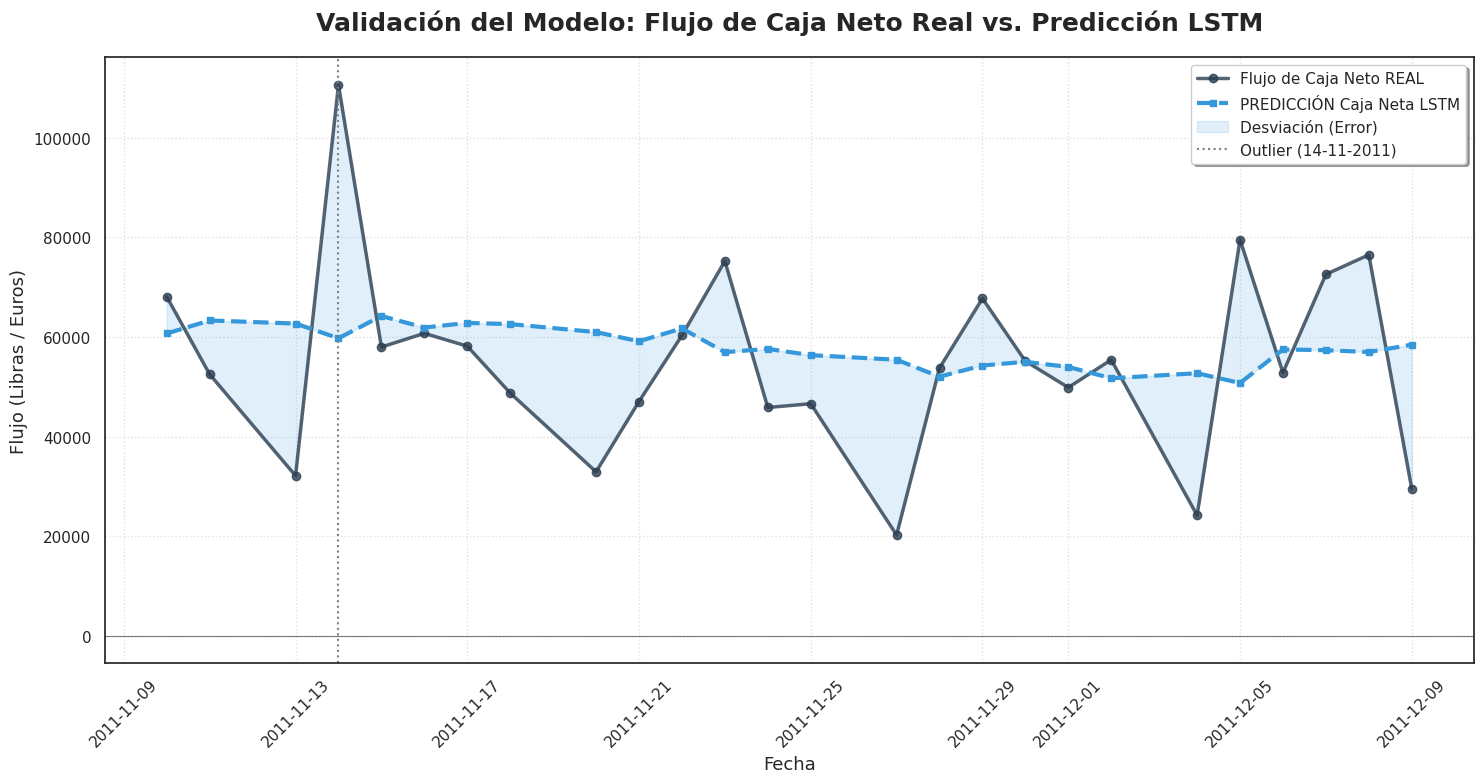

In [5]:
# =============================================================================
# 5. VISUALIZACIÓN
# =============================================================================
sns.set_theme(style="white")
plt.figure(figsize=(15, 8))

# Línea de referencia (Caja Neta Real)
plt.plot(df_mes_objetivo['Fecha'], df_mes_objetivo['Ventas_Netas_Reales'],
         label='Flujo de Caja Neto REAL', color='#2C3E50',
         linewidth=2.5, marker='o', markersize=6, alpha=0.8)

# Línea de Predicción (Caja Neta Predicha)
plt.plot(df_mes_objetivo['Fecha'], df_mes_objetivo['Ventas_Netas_Predichas'],
         label='PREDICCIÓN Caja Neta LSTM', color='#3498DB',
         linewidth=3, linestyle='--', marker='s', markersize=4)

# Sombreado de Desviación
plt.fill_between(df_mes_objetivo['Fecha'],
                 df_mes_objetivo['Ventas_Netas_Reales'],
                 df_mes_objetivo['Ventas_Netas_Predichas'],
                 color='#3498DB', alpha=0.15, label='Desviación (Error)')

# Marcador visual del Outlier
plt.axvline(x=fecha_anomala, color='gray', linestyle=':', label='Outlier (14-11-2011)')

# Estética
plt.title('Validación del Modelo: Flujo de Caja Neto Real vs. Predicción LSTM', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Fecha', fontsize=13)
plt.ylabel('Flujo (Libras / Euros)', fontsize=13)
plt.xticks(rotation=45)
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()